<a href="https://colab.research.google.com/github/ipeirotis-org/datasets/blob/main/NBA/Knicks_2026_rolling_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rolling-Window Analysis of the Knicks' 2026 Title Run

This notebook extends the 2026 Finals segment study in two ways:

1. **Rolling (overlapping) windows** instead of fixed non-overlapping segments. We slide a window
   of length L across each game and ask, over **every** possible window position, what share favor
   the Knicks. This removes the arbitrariness of where segment boundaries fall (it is the limit of
   averaging the earlier offset sweep over all offsets).
2. **The full 19-game playoff run** (Round 1 through the Finals), so the Finals can be compared with
   the rounds that came before it.

**Headline finding (preview).** Through the first three rounds the Knicks won a clear majority of
rolling windows (Round 1 about 60%, Conference Semifinals about 65%, Conference Finals about 58%).
In the Finals that edge vanished: they won only about 46% of rolling windows, essentially even with
San Antonio. The Knicks dominated the minutes on their way to the Finals, then won the title itself
on timing and clutch play rather than by out-playing the Spurs minute for minute.

### How this notebook is organized
* Section 1 sets up imports and shared constants.
* Section 2 loads the per-event scoring data (and documents how it is built from the NBA API).
* Section 3 defines the rolling-window method and validates it against a brute-force grid.
* Sections 4 to 8 produce the results: full run vs Finals, a window-length sweep, a by-round
  comparison, a per-game view, and a continuous time profile.
* Section 9 reconciles the rolling and non-overlapping methods and states the conclusions.

Every helper function below carries a docstring describing its inputs and outputs, and the
non-obvious steps are commented inline.


## 1. Setup

We rely only on `numpy`, `pandas`, and `matplotlib`. The constants gathered here are referenced
throughout, so the analysis parameters live in one place.


In [15]:
!pip install -q nba_api

%config InlineBackend.figure_format = 'retina'

import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ---- Plot styling (kept consistent across every figure) -------------------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,   # grid lines sit behind the data
    "font.size": 10,
})

# ---- Team / round constants -----------------------------------------------------------------
NYK_BLUE   = "#006BB6"   # Knicks colors, used for "win" elements
NYK_ORANGE = "#F58426"   # used for "loss" elements and for the Finals series
NEUTRAL    = "#9aa0a6"   # used for ties

# Playoff rounds in chronological order, with a color shading that darkens as rounds advance.
ROUND_ORDER = ["R1", "ConfSemis", "ConfFinals", "Finals"]
ROUND_COLOR = {
    "R1":         "#7BAFD4",
    "ConfSemis":  "#5C8FB8",
    "ConfFinals": "#2E6E9E",
    "Finals":     NYK_ORANGE,
}

# ---- Analysis constants ---------------------------------------------------------------------
SECONDS_PER_MINUTE = 60.0
REGULATION_GAME_SECONDS = 2880.0   # 4 quarters x 12 minutes; overtime games run longer
EVENTS_CSV = "knicks_2026_playoffs_events.csv"

# Window lengths (minutes) used by the sweeps. PRIMARY_WINDOW_MIN is used only for the two
# single-length visuals (per-game dominance in Section 7 and the time profile in Section 8);
# change it to view those at a different length. The comparisons in Sections 4 to 6 run across
# the whole list rather than a single length.
WINDOW_LENGTHS_MIN = [1, 2, 3, 4, 6, 8, 12]
PRIMARY_WINDOW_MIN = 2


## 2. Data: every 2026 playoff game

The unit of analysis is a **scoring event**: an elapsed game time together with the points the
Knicks or their opponent scored at that moment. The loader below reads a bundled CSV so the
notebook runs offline and deterministically; it only calls the NBA API if the CSV is missing.

The rebuild function documents the full extraction, including the one data quirk that matters:
older play-by-play feeds write a literal `0-0` on non-scoring rows rather than leaving them blank,
so a naive forward-fill of the running score would reset the score to zero on those rows. We mask
the rows where both scores are zero before forward-filling, which leaves only the genuine pre-tipoff
`0-0` to be filled.


In [6]:
def parse_clock_to_seconds_remaining(clock_string):
    '''Convert an NBA clock string such as "PT07M36.00S" into seconds remaining in the period.'''
    match = re.match(r"PT(\d+)M([\d.]+)S", clock_string)
    if match is None:
        return None
    minutes, seconds = int(match.group(1)), float(match.group(2))
    return minutes * 60 + seconds


def period_length_seconds(period_number):
    '''Length of a period in seconds: 12 minutes for regulation (1 to 4), 5 minutes for overtime.'''
    return 720.0 if period_number <= 4 else 300.0


def elapsed_at_period_start(period_number):
    '''Elapsed game seconds already played when a given period begins.'''
    if period_number <= 4:
        return (period_number - 1) * 720.0
    # After four 12-minute quarters, each overtime adds 5 minutes.
    overtime_index = period_number - 5
    return 4 * 720.0 + overtime_index * 300.0


def event_elapsed_seconds(period_number, clock_string):
    '''Elapsed seconds since tipoff for an event, from its period and remaining-time clock.'''
    remaining = parse_clock_to_seconds_remaining(clock_string)
    if remaining is None:
        return None
    seconds_into_period = period_length_seconds(period_number) - remaining
    return elapsed_at_period_start(period_number) + seconds_into_period


def build_playoff_events(path=EVENTS_CSV):
    '''
    Build the per-event scoring table for every Knicks 2026 playoff game from the NBA API.

    For each game we reconstruct the running score, take the per-event change for each team,
    convert the clock to elapsed seconds, and keep only the rows where someone scored. The
    resulting columns are:
        seq         chronological game number (1..19)
        game_id     NBA game id
        round       R1 / ConfSemis / ConfFinals / Finals (decoded from the game id)
        opp         opponent abbreviation
        nyk_home    True if the Knicks were the home team
        nyk_result  "W" or "L" for the Knicks in that game
        elapsed     event time in seconds since tipoff
        nyk, sas    points the Knicks / opponent scored on this event
        T           total length of the game in seconds (2880, or more with overtime)
    '''
    from nba_api.stats.endpoints import leaguegamefinder, playbyplayv3

    # The 6th and 7th characters of a playoff game id encode the round.
    round_from_game_id = {"001": "R1", "002": "ConfSemis", "003": "ConfFinals", "004": "Finals"}

    finder = leaguegamefinder.LeagueGameFinder(
        season_nullable="2025-26", season_type_nullable="Playoffs",
        league_id_nullable="00", timeout=45)
    knicks_games = finder.get_data_frames()[0]
    knicks_games = knicks_games[knicks_games.TEAM_ABBREVIATION == "NYK"].sort_values("GAME_DATE")

    event_rows = []
    for game_seq, (_, game_row) in enumerate(knicks_games.iterrows(), start=1):
        game_id = game_row.GAME_ID
        knicks_are_home = "vs." in game_row.MATCHUP        # MATCHUP reads "NYK vs. OPP" or "NYK @ OPP"
        opponent = game_row.MATCHUP.split()[-1]

        pbp = playbyplayv3.PlayByPlayV3(game_id=game_id, timeout=45).get_data_frames()[0]

        # Reconstruct the running score. Non-scoring rows in older feeds carry a literal 0-0,
        # so mask both-zero rows to missing before forward-filling, then treat any remaining
        # leading gap (the true pre-tipoff state) as 0-0.
        home_score = pd.to_numeric(pbp.scoreHome, errors="coerce")
        away_score = pd.to_numeric(pbp.scoreAway, errors="coerce")
        non_scoring = (home_score == 0) & (away_score == 0)
        home_score = home_score.mask(non_scoring).ffill().fillna(0)
        away_score = away_score.mask(non_scoring).ffill().fillna(0)

        pbp["elapsed"] = [event_elapsed_seconds(p, c) for p, c in zip(pbp.period, pbp.clock)]
        pbp = pbp.dropna(subset=["elapsed"]).reset_index(drop=True)

        # Per-event points = change in running score since the previous row (clip away any
        # spurious negative diffs; the running score is monotone non-decreasing).
        home_points = home_score.diff().fillna(home_score).clip(lower=0)
        away_points = away_score.diff().fillna(away_score).clip(lower=0)
        knicks_points, opp_points = (home_points, away_points) if knicks_are_home else (away_points, home_points)

        game_length = pbp.elapsed.max()
        for elapsed, nyk_pts, opp_pts in zip(pbp.elapsed, knicks_points, opp_points):
            if nyk_pts > 0 or opp_pts > 0:
                event_rows.append({
                    "seq": game_seq, "game_id": game_id,
                    "round": round_from_game_id.get(game_id[5:8], game_id[5:8]),
                    "opp": opponent, "nyk_home": knicks_are_home, "nyk_result": game_row.WL,
                    "elapsed": round(elapsed, 1), "nyk": int(nyk_pts), "sas": int(opp_pts),
                    "T": game_length,
                })
        time.sleep(0.25)   # be polite to the API between games

    events = pd.DataFrame(event_rows)
    events.to_csv(path, index=False)
    return events


# Load from the bundled CSV if present, otherwise rebuild from the API.
if os.path.exists(EVENTS_CSV):
    events = pd.read_csv(EVENTS_CSV)
else:
    events = build_playoff_events()

# Series-level summary of the run (one row per game).
game_summary = (events
                .groupby(["seq", "round", "opp", "nyk_result"])
                .agg(nyk_points=("nyk", "sum"), opp_points=("sas", "sum"), length_s=("T", "first"))
                .reset_index())
wins = (game_summary.nyk_result == "W").sum()
losses = (game_summary.nyk_result == "L").sum()
print(f"2026 playoff record: {wins}-{losses} over {game_summary.seq.nunique()} games")
game_summary


2026 playoff record: 16-3 over 19 games


,seq,round,opp,nyk_result,nyk_points,opp_points,length_s
0,1,R1,ATL,W,113,102,2880.0
1,2,R1,ATL,L,106,107,2880.0
2,3,R1,ATL,L,108,109,2880.0
3,4,R1,ATL,W,114,98,2880.0
4,5,R1,ATL,W,126,97,2880.0
5,6,R1,ATL,W,140,89,2880.0
6,7,ConfSemis,PHI,W,137,98,2880.0
7,8,ConfSemis,PHI,W,108,102,2880.0
8,9,ConfSemis,PHI,W,108,94,2880.0
9,10,ConfSemis,PHI,W,144,114,2880.0


## 3. Method: rolling windows by exact integration

Fix a window length L. The net Knicks points inside a window that **starts** at time `a` and ends at
`a + L` is the running Knicks margin at the end minus the margin at the start:

```
net(a) = margin(a + L) - margin(a)
```

where `margin(t)` is cumulative Knicks points minus opponent points up to time t.

As the start `a` slides from 0 to `game_length - L`, `net(a)` is a **step function**: it changes only
when a scoring event crosses the trailing edge of the window (at `a = event_time`) or the leading edge
(at `a = event_time - L`). Between consecutive crossings `net(a)` is constant. We therefore collect
those crossing points as breakpoints, and on each constant interval we evaluate `net` once at the
midpoint and add the interval length to a win, tie, or loss total according to its sign. The result is
the **exact** share of all window positions favoring the Knicks, with no sampling step to choose.


In [7]:
def running_margin_timeline(events_for_game):
    '''
    Build the running Knicks margin for one game as a pair of aligned arrays.

    Returns:
        event_times       sorted array of elapsed times (seconds) at which scoring occurred
        cumulative_margin cumulative_margin[i] is Knicks-minus-opponent points immediately
                          after the event at event_times[i]
    '''
    ordered = events_for_game.sort_values("elapsed")
    event_times = ordered["elapsed"].to_numpy(dtype=float)
    per_event_change = (ordered["nyk"] - ordered["sas"]).to_numpy(dtype=float)
    cumulative_margin = np.cumsum(per_event_change)
    return event_times, cumulative_margin


def margin_at_time(event_times, cumulative_margin, t):
    '''
    Knicks running margin at elapsed time t.

    The margin at t is the sum of all event deltas with event time <= t. Because event_times is
    sorted, np.searchsorted(..., side="right") returns the count of events at or before t, and the
    margin we want is the cumulative value just before that index. Before the first event it is 0.
    '''
    events_through_t = np.searchsorted(event_times, t, side="right")
    if events_through_t == 0:
        return 0.0
    return cumulative_margin[events_through_t - 1]


def rolling_window_breakdown_for_game(events_for_game, window_length_s, game_length_s):
    '''
    Exact win / tie / loss split of all rolling-window start positions for one game.

    See Section 3 for the derivation. We integrate net(a) = margin(a + L) - margin(a) over the
    start axis a in [0, game_length - L] by splitting that axis at every point where net(a) can
    change, namely each event time (trailing-edge crossing) and each event time minus L
    (leading-edge crossing).

    Returns:
        (win_seconds, tie_seconds, loss_seconds, start_axis_length), or None if the window is
        longer than the game and therefore does not fit.
    '''
    event_times, cumulative_margin = running_margin_timeline(events_for_game)
    max_start = game_length_s - window_length_s
    if max_start <= 0:
        return None

    # Collect the breakpoints of net(a) inside the open interval (0, max_start), plus the endpoints.
    breakpoints = {0.0, max_start}
    for event_time in event_times:
        trailing_edge_crossing = event_time             # window start reaches this event
        leading_edge_crossing = event_time - window_length_s   # window end reaches this event
        if 0.0 < trailing_edge_crossing < max_start:
            breakpoints.add(float(trailing_edge_crossing))
        if 0.0 < leading_edge_crossing < max_start:
            breakpoints.add(float(leading_edge_crossing))
    breakpoints = sorted(breakpoints)

    win_seconds = tie_seconds = loss_seconds = 0.0
    for i in range(len(breakpoints) - 1):
        interval_start = breakpoints[i]
        interval_end = breakpoints[i + 1]
        interval_length = interval_end - interval_start

        # net(a) is constant on this interval; evaluate it at the midpoint.
        midpoint = 0.5 * (interval_start + interval_end)
        net_points = (margin_at_time(event_times, cumulative_margin, midpoint + window_length_s)
                      - margin_at_time(event_times, cumulative_margin, midpoint))

        if net_points > 0:
            win_seconds += interval_length
        elif net_points < 0:
            loss_seconds += interval_length
        else:
            tie_seconds += interval_length

    return win_seconds, tie_seconds, loss_seconds, max_start


def pool_rolling_windows(events_subset, window_length_min):
    '''
    Aggregate the exact rolling-window outcome across a set of games.

    Each game contributes win / tie / loss seconds along its own start axis. Pooling sums those
    seconds across games, which weights a game by the length of its start axis (nearly identical
    for all regulation games).

    Returns:
        pooled    dict with keys win_pct, tie_pct, loss_pct (shares over all window positions)
        per_game  DataFrame with one row per game and the same three percentages
    '''
    window_length_s = window_length_min * SECONDS_PER_MINUTE
    total_win = total_tie = total_loss = total_start_axis = 0.0
    per_game_rows = []

    for game_seq, events_for_game in events_subset.groupby("seq"):
        game_length_s = events_for_game["T"].iloc[0]
        breakdown = rolling_window_breakdown_for_game(events_for_game, window_length_s, game_length_s)
        if breakdown is None:
            continue
        win_s, tie_s, loss_s, start_axis = breakdown

        total_win += win_s
        total_tie += tie_s
        total_loss += loss_s
        total_start_axis += start_axis

        per_game_rows.append({
            "seq": game_seq,
            "round": events_for_game["round"].iloc[0],
            "opp": events_for_game["opp"].iloc[0],
            "result": events_for_game["nyk_result"].iloc[0],
            "win_pct": 100 * win_s / start_axis,
            "tie_pct": 100 * tie_s / start_axis,
            "loss_pct": 100 * loss_s / start_axis,
        })

    pooled = {
        "win_pct": 100 * total_win / total_start_axis,
        "tie_pct": 100 * total_tie / total_start_axis,
        "loss_pct": 100 * total_loss / total_start_axis,
    }
    return pooled, pd.DataFrame(per_game_rows)


### Validation against a brute-force grid

The exact integration should match a discrete grid that simply steps the window start by a fixed
amount and counts. As the grid spacing shrinks, the grid estimate must converge to the exact value.


In [8]:
def rolling_window_winshare_grid(events_subset, window_length_min, step_seconds):
    '''
    Approximate the Knicks win share by sampling window-start positions on a fixed grid.

    This is intentionally simple and slow: it exists only to cross-check the exact integration in
    rolling_window_breakdown_for_game. Returns the percentage of sampled positions favoring NYK.
    '''
    window_length_s = window_length_min * SECONDS_PER_MINUTE
    positions_won = positions_total = 0

    for _, events_for_game in events_subset.groupby("seq"):
        game_length_s = events_for_game["T"].iloc[0]
        event_times, cumulative_margin = running_margin_timeline(events_for_game)
        for start in np.arange(0, game_length_s - window_length_s + 1e-9, step_seconds):
            net_points = (margin_at_time(event_times, cumulative_margin, start + window_length_s)
                          - margin_at_time(event_times, cumulative_margin, start))
            positions_total += 1
            if net_points > 0:
                positions_won += 1
    return 100 * positions_won / positions_total


exact_win_share = pool_rolling_windows(events, window_length_min=PRIMARY_WINDOW_MIN)[0]["win_pct"]
print(f"exact integration          : {exact_win_share:.3f}%")
for step in [30, 10, 5, 1]:
    grid_estimate = rolling_window_winshare_grid(events, window_length_min=PRIMARY_WINDOW_MIN, step_seconds=step)
    print(f"grid sampling every {step:>3}s : {grid_estimate:.3f}%")


exact integration          : 50.723%
grid sampling every  30s : 50.816%
grid sampling every  10s : 50.690%
grid sampling every   5s : 50.743%
grid sampling every   1s : 50.733%


## 4. Core result across window lengths: full playoffs vs Finals

Rather than fix a single window, we compute the win / tie / loss split at every length in
`WINDOW_LENGTHS_MIN`, for the whole run and for the Finals alone. Reading down a column shows how the
outcome shifts as the window grows; comparing the two tables shows how different the Finals were from
the rounds that led up to them.


In [9]:
finals_events = events[events["round"] == "Finals"]


def rolling_sweep_table(events_subset, window_lengths_min=WINDOW_LENGTHS_MIN):
    '''
    Win / tie / loss percentages at each window length for one set of games.

    Returns a DataFrame with one row per length and columns:
        window_min, win_pct, tie_pct, loss_pct
    '''
    rows = []
    for window_length_min in window_lengths_min:
        pooled, _ = pool_rolling_windows(events_subset, window_length_min)
        rows.append({"window_min": window_length_min,
                     "win_pct": pooled["win_pct"],
                     "tie_pct": pooled["tie_pct"],
                     "loss_pct": pooled["loss_pct"]})
    return pd.DataFrame(rows)


full_sweep = rolling_sweep_table(events)
finals_sweep = rolling_sweep_table(finals_events)

print("Full playoffs (19 games) - rolling window outcome by window length:")
print(full_sweep.round(1).to_string(index=False))
print("\nFinals only (5 games):")
print(finals_sweep.round(1).to_string(index=False))


Full playoffs (19 games) - rolling window outcome by window length:
 window_min  win_pct  tie_pct  loss_pct
          1     44.7     20.5      34.8
          2     50.7     12.0      37.3
          3     54.6      8.7      36.6
          4     56.8      7.1      36.2
          6     60.3      6.0      33.7
          8     63.1      5.2      31.7
         12     67.2      3.7      29.1

Finals only (5 games):
 window_min  win_pct  tie_pct  loss_pct
          1     40.3     20.5      39.3
          2     43.4     12.2      44.4
          3     46.8      9.8      43.5
          4     46.2      6.7      47.1
          6     46.5      5.7      47.7
          8     47.8      4.2      48.0
         12     52.9      3.2      43.9


## 5. Window-length sweep, showing ties as well as wins

The two tables above, drawn. Each panel plots the win, tie, and loss shares as the window grows.
Ties are largest at the shortest windows (many brief windows are exact trade-blow stretches) and
shrink as the window lengthens. The full run climbs well above the even line with longer windows,
the signature of out-playing opponents over stretches; the Finals stay pinned near even at every
length.


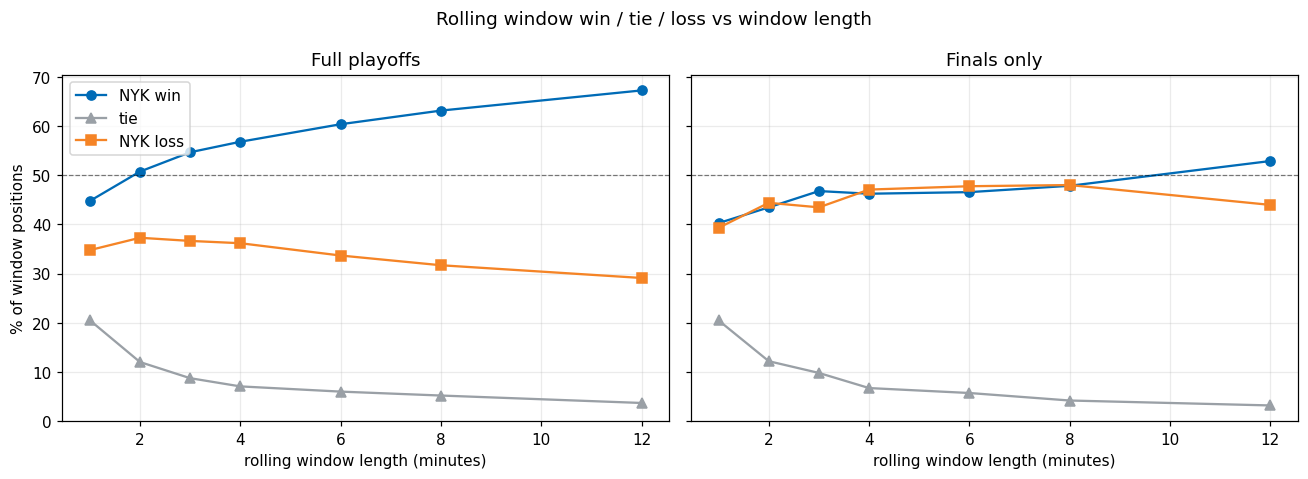

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)

for ax, panel_title, sweep in [(axes[0], "Full playoffs", full_sweep),
                               (axes[1], "Finals only", finals_sweep)]:
    ax.plot(sweep.window_min, sweep.win_pct,  "o-", color=NYK_BLUE,   label="NYK win")
    ax.plot(sweep.window_min, sweep.tie_pct,  "^-", color=NEUTRAL,    label="tie")
    ax.plot(sweep.window_min, sweep.loss_pct, "s-", color=NYK_ORANGE, label="NYK loss")
    ax.axhline(50, ls="--", lw=0.8, color="k", alpha=0.5)   # even reference line
    ax.set_title(panel_title)
    ax.set_xlabel("rolling window length (minutes)")

axes[0].set_ylabel("% of window positions")
axes[0].legend()
fig.suptitle("Rolling window win / tie / loss vs window length")
plt.tight_layout()
plt.show()


## 6. By-round comparison across window lengths

For each round we sweep the window length and record the Knicks win share, so the round comparison is
not tied to a single window either. The Conference Semifinals sit highest and climb steeply with
window length; the Finals sit lowest and stay flat near even. A companion table reports the tie
shares, and the final bar chart is a single-length snapshot at `PRIMARY_WINDOW_MIN`.


NYK win % by round and window length:
              R1  ConfSemis  ConfFinals  Finals
window_min                                     
1           46.1       47.6        45.4    40.3
2           52.4       56.9        51.1    43.4
3           55.3       63.5        54.7    46.8
4           59.5       64.7        57.9    46.2
6           64.0       70.2        62.1    46.5
8           65.6       74.2        67.3    47.8
12          69.9       80.7        67.7    52.9

Tie % by round and window length:
              R1  ConfSemis  ConfFinals  Finals
window_min                                     
1           19.6       22.3        20.1    20.5
2           10.9       14.1        11.3    12.2
3            9.4        8.0         7.2     9.8
4            8.1        8.1         4.9     6.7
6            6.0        6.8         5.5     5.7
8            5.4        7.2         4.2     4.2
12           4.3        4.2         2.8     3.2


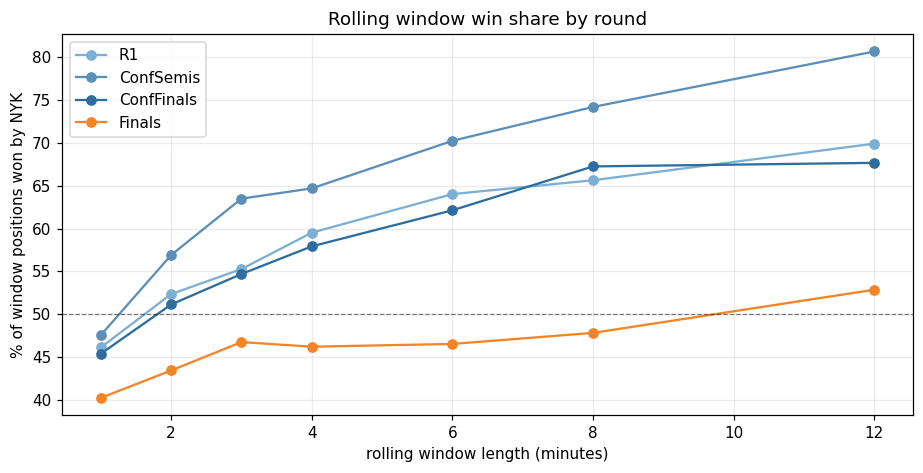

In [11]:
def by_round_metric_table(metric, window_lengths_min=WINDOW_LENGTHS_MIN):
    '''
    Build a (window length) x (round) table for one metric.

    metric is one of "win_pct", "tie_pct", "loss_pct". Rows are window lengths, columns are rounds.
    '''
    columns = {}
    for round_name in ROUND_ORDER:
        round_sweep = rolling_sweep_table(events[events["round"] == round_name], window_lengths_min)
        columns[round_name] = round_sweep.set_index("window_min")[metric]
    return pd.DataFrame(columns)


win_by_round = by_round_metric_table("win_pct")
tie_by_round = by_round_metric_table("tie_pct")
print("NYK win % by round and window length:")
print(win_by_round.round(1).to_string())
print("\nTie % by round and window length:")
print(tie_by_round.round(1).to_string())

# Win share vs window length, one line per round.
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for round_name in ROUND_ORDER:
    ax.plot(win_by_round.index, win_by_round[round_name], "o-",
            color=ROUND_COLOR[round_name], label=round_name)
ax.axhline(50, ls="--", lw=0.8, color="k", alpha=0.5)
ax.set_xlabel("rolling window length (minutes)")
ax.set_ylabel("% of window positions won by NYK")
ax.set_title("Rolling window win share by round")
ax.legend()
plt.tight_layout()
plt.show()


Single-length snapshot at `PRIMARY_WINDOW_MIN`, as stacked win / tie / loss shares per round.

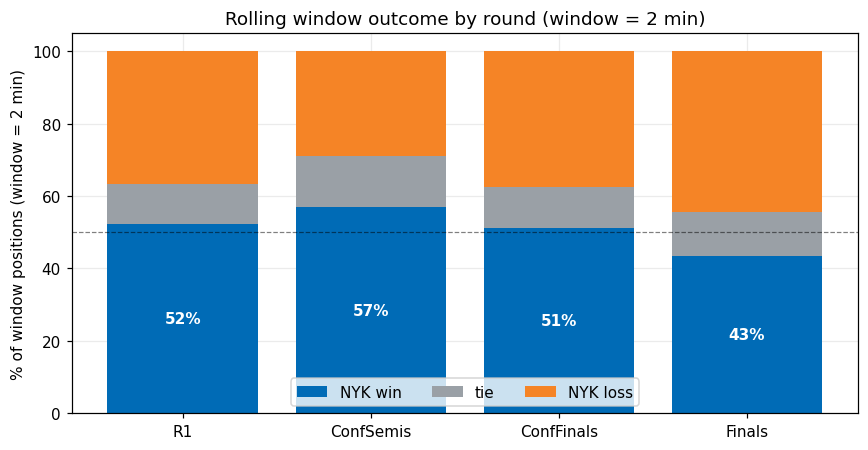

In [12]:
round_positions = np.arange(len(ROUND_ORDER))
win_share, tie_share, loss_share = [], [], []
for round_name in ROUND_ORDER:
    pooled, _ = pool_rolling_windows(events[events["round"] == round_name], PRIMARY_WINDOW_MIN)
    win_share.append(pooled["win_pct"])
    tie_share.append(pooled["tie_pct"])
    loss_share.append(pooled["loss_pct"])
win_share = np.array(win_share)
tie_share = np.array(tie_share)
loss_share = np.array(loss_share)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(round_positions, win_share, color=NYK_BLUE, label="NYK win")
ax.bar(round_positions, tie_share, bottom=win_share, color=NEUTRAL, label="tie")
ax.bar(round_positions, loss_share, bottom=win_share + tie_share, color=NYK_ORANGE, label="NYK loss")

# Annotate each bar with its win share.
for x, share in zip(round_positions, win_share):
    ax.text(x, share / 2, f"{share:.0f}%", ha="center", va="center", color="white", fontweight="bold")

ax.axhline(50, ls="--", lw=0.8, color="k", alpha=0.5)
ax.set_xticks(round_positions)
ax.set_xticklabels(ROUND_ORDER)
ax.set_ylabel(f"% of window positions (window = {PRIMARY_WINDOW_MIN} min)")
ax.set_title(f"Rolling window outcome by round (window = {PRIMARY_WINDOW_MIN} min)")
ax.legend(ncol=3, loc="lower center")
plt.tight_layout()
plt.show()


## 7. Per-game window dominance

Each game reduced to one number: the share of `PRIMARY_WINDOW_MIN`-minute window positions the Knicks
won, colored by round. Games above the dashed even line are ones the Knicks controlled minute for
minute; the close Finals games cluster near or below it.


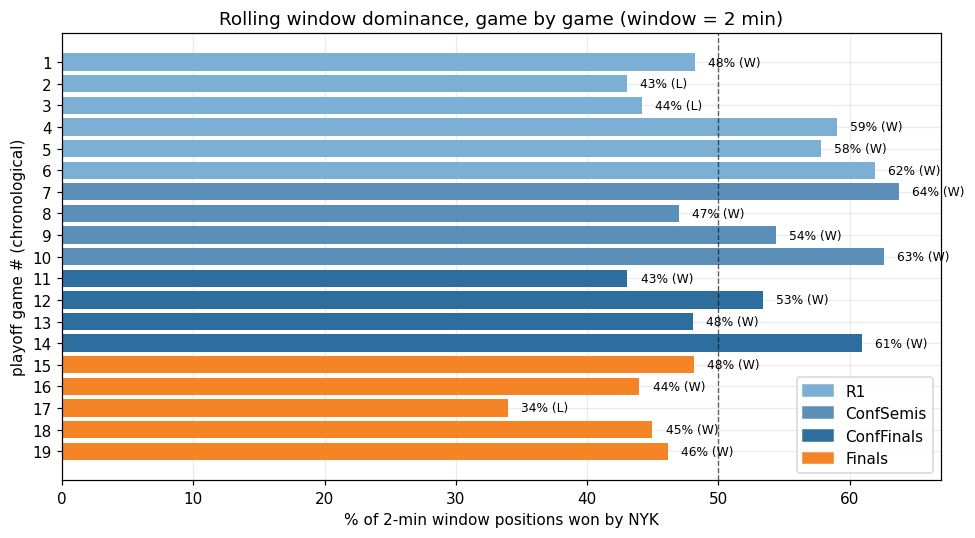

In [13]:
_, per_game = pool_rolling_windows(events, window_length_min=PRIMARY_WINDOW_MIN)
per_game = per_game.sort_values("seq")

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [ROUND_COLOR[r] for r in per_game["round"]]
ax.barh(per_game.seq.astype(str), per_game.win_pct, color=bar_colors)

# Label each bar with the win share and the game result.
for game_seq, win_pct, result in zip(per_game.seq, per_game.win_pct, per_game.result):
    ax.text(win_pct + 1, str(game_seq), f"{win_pct:.0f}% ({result})", va="center", fontsize=8)

ax.axvline(50, ls="--", lw=0.9, color="k", alpha=0.6)
ax.set_xlabel(f"% of {PRIMARY_WINDOW_MIN}-min window positions won by NYK")
ax.set_ylabel("playoff game # (chronological)")
ax.invert_yaxis()   # game 1 at the top

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=ROUND_COLOR[r]) for r in ROUND_ORDER]
ax.legend(legend_handles, ROUND_ORDER, loc="lower right")
ax.set_title(f"Rolling window dominance, game by game (window = {PRIMARY_WINDOW_MIN} min)")
plt.tight_layout()
plt.show()


## 8. Time profile: when did the Knicks win the windows?

Here we slide the window and record, for each clock position, the average Knicks net points in the
window **centered** there, averaged across games. This traces continuously when in a typical game the
Knicks were out-scoring the opponent. We compare the full-playoff profile with the Finals profile over
regulation only (the single overtime game contributes just its regulation portion, so the curves stay
comparable). The early dip followed by a mid-game surge is the comeback signature seen earlier in the
quarter splits.


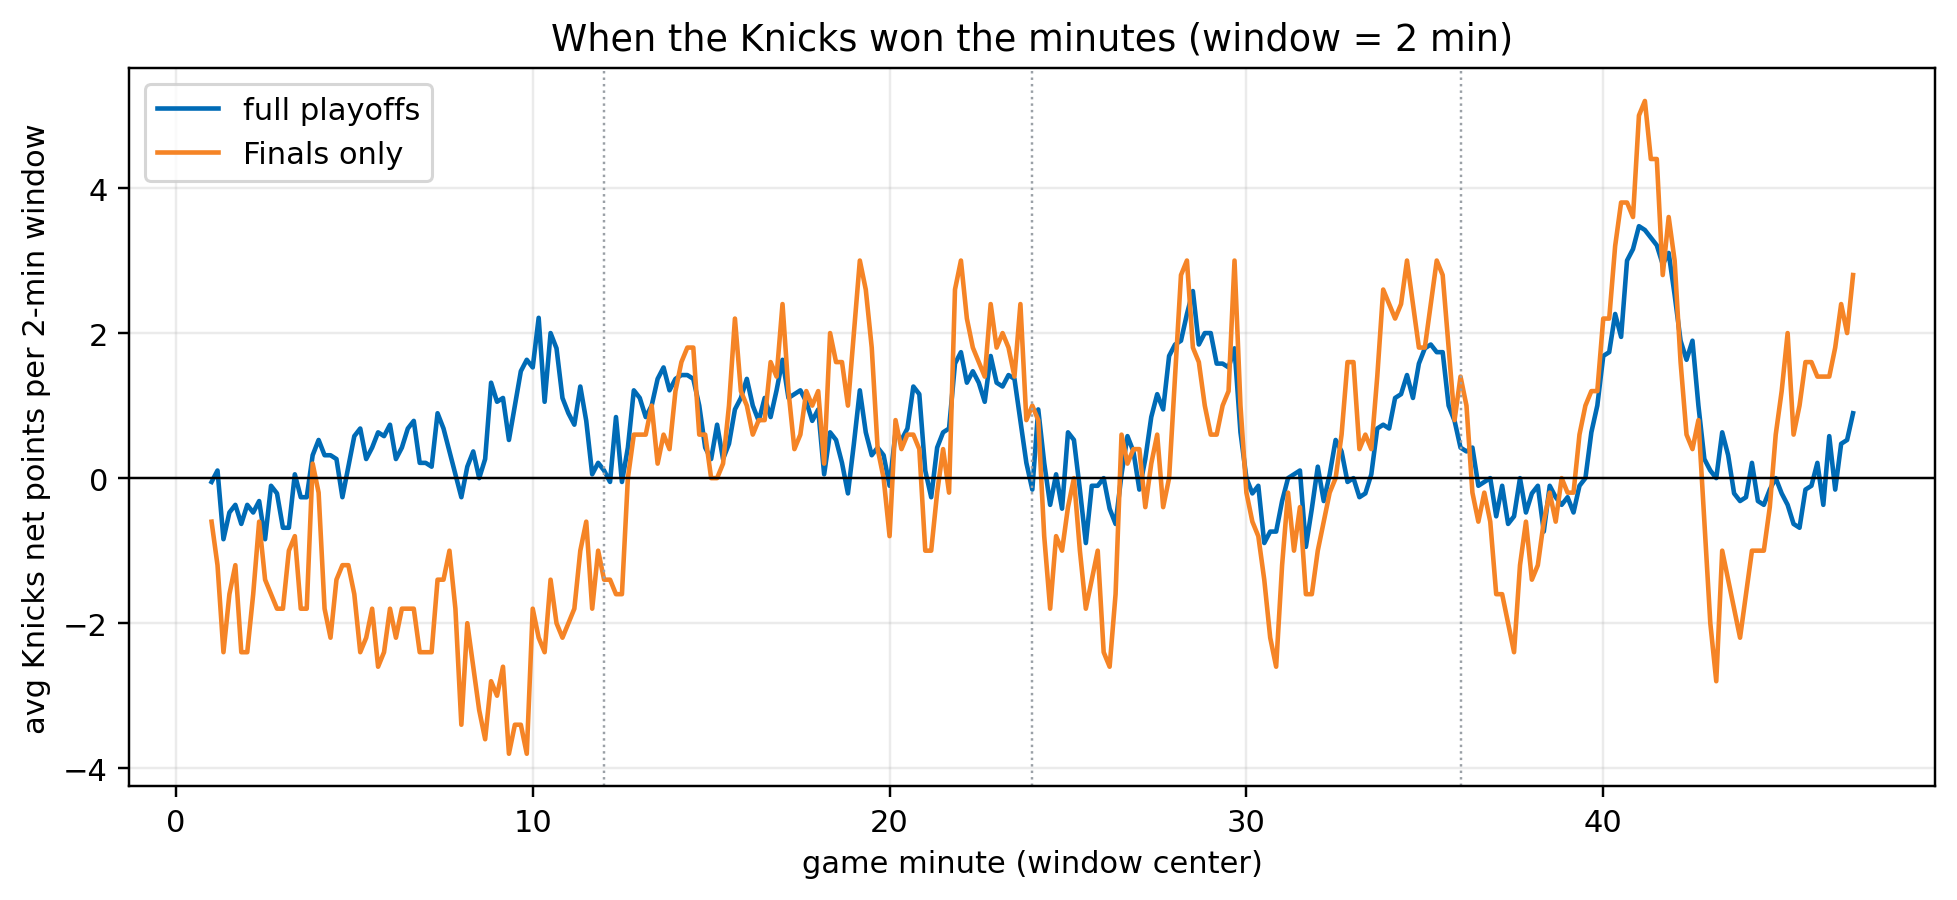

In [22]:
def window_centered_time_profile(events_subset, window_length_min,
                                 step_seconds=10.0, horizon_seconds=REGULATION_GAME_SECONDS):
    '''
    Average Knicks net points in a window centered at each clock position, across games.

    For each center time c, the window spans [c - L/2, c + L/2); its net is
    margin(c + L/2) - margin(c - L/2). We average that across all games long enough to contain the
    window at c. Returns (center_minutes, average_net_points) as aligned arrays.
    '''
    window_length_s = window_length_min * SECONDS_PER_MINUTE
    half_window = window_length_s / 2.0
    centers = np.arange(half_window, horizon_seconds - half_window + 1e-9, step_seconds)

    net_sum = np.zeros(len(centers))
    game_count = np.zeros(len(centers))
    for _, events_for_game in events_subset.groupby("seq"):
        game_length_s = events_for_game["T"].iloc[0]
        event_times, cumulative_margin = running_margin_timeline(events_for_game)
        for i, center in enumerate(centers):
            if center + half_window <= game_length_s:   # window fits inside this game
                net = (margin_at_time(event_times, cumulative_margin, center + half_window)
                       - margin_at_time(event_times, cumulative_margin, center - half_window))
                net_sum[i] += net
                game_count[i] += 1

    average_net = np.divide(net_sum, game_count, out=np.zeros_like(net_sum), where=game_count > 0)
    return centers / SECONDS_PER_MINUTE, average_net


full_centers, full_profile = window_centered_time_profile(events, window_length_min=PRIMARY_WINDOW_MIN)
finals_centers, finals_profile = window_centered_time_profile(finals_events, window_length_min=PRIMARY_WINDOW_MIN)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(full_centers, full_profile, color=NYK_BLUE, label="full playoffs")
ax.plot(finals_centers, finals_profile, color=NYK_ORANGE, label="Finals only")
ax.axhline(0, color="k", lw=0.8)
for quarter_break_minute in [12, 24, 36]:    # quarter boundaries
    ax.axvline(quarter_break_minute, ls=":", lw=0.8, color=NEUTRAL)
ax.set_xlabel("game minute (window center)")
ax.set_ylabel(f"avg Knicks net points per {PRIMARY_WINDOW_MIN}-min window")
ax.set_title(f"When the Knicks won the minutes (window = {PRIMARY_WINDOW_MIN} min)")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Rolling vs non-overlapping, and conclusions

**Rolling vs the earlier non-overlapping segments.** For the Finals, the non-overlapping method gave
about 51.7% of 4-minute windows won, but that figure depended on where the segment boundaries fell
(the offset sweep ranged roughly 41 to 52%). The rolling integration removes that dependence and lands
at about 46%, matching the offset-averaged value. The rolling number is the more honest single summary
because it weights every window position equally.

**What the full run shows.**
* Through three rounds the Knicks won a clear majority of rolling windows (Round 1 about 60%,
  Conference Semifinals about 65%, Conference Finals about 58%), and the win share rose with window
  length, the signature of genuinely out-playing opponents over stretches.
* In the Finals the win share fell to about 46% and stayed near even at every window length. They did
  not out-play San Antonio minute for minute; they won on timing.
* The time profile shows the same comeback shape in both samples, early deficits followed by a
  mid-game surge, but it is far more pronounced and less decisive in the Finals.

**Caveats.**
* Rolling windows count overlapping positions, so they measure how favorable the typical window was,
  not a count of independent contests. Pooling weights each game by its window-start range, which is
  nearly equal across games.
* Five Finals games and 19 playoff games are small samples; round-level numbers move with a single
  swing game.
* The time profile averages across games over regulation only; the one overtime game contributes just
  its regulation portion to the shared curve.
